# Imports

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
%matplotlib inline

In [21]:
plt . style . available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [32]:
plt.style.use("tableau-colorblind10")

# 1.1 Tarefa 1: Estatísticas Descritivas e Visualizações Básicas

## 1 Distribuição e Gols

In [8]:
df = pd.read_csv("./futebol.csv")

In [9]:
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,2005-08-28,23,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,São Paulo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,2005-06-26,9,Estádio Olímpico Nilton Santos,NaN,NaN,NaN,Botafogo,Figueirense FC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Crie coluna gols_total = gols_mandante + gols_visitante
df.loc[:, "gols_total"] = df["gols_mandante"] + df["gols_visitante"]

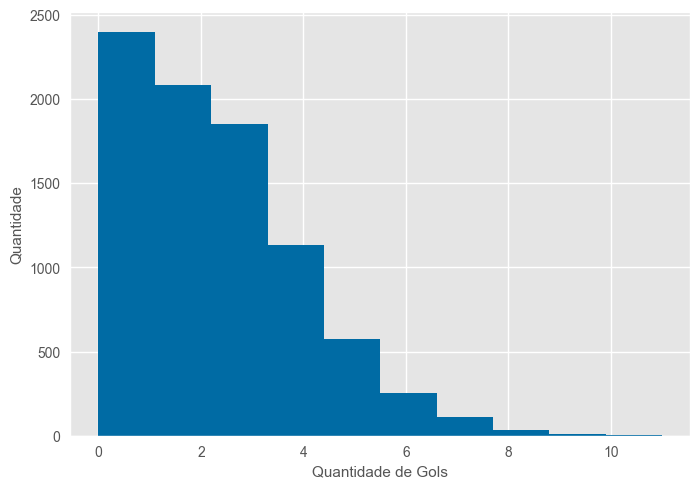

In [33]:
# Histograma da distribuição de gols totais
plt.hist(data=df,
             x="gols_total")
plt.xlabel("Quantidade de Gols")
plt.ylabel("Quantidade")
plt.show()

In [44]:
Q1 = df['gols_total'].quantile(0.25)
Q3 = df['gols_total'].quantile(0.75)
InterQuartil = Q3 - Q1

In [45]:
# Calcule: média, mediana, moda, desvio padrão, IQR
df_medidas = {
    "Média" : round(df["gols_total"].mean(), 3),
    "Mediana" :round(df["gols_total"].median(), 3),
    "Moda" :df['gols_total'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_total"].std(), 2),
    "IQR" :InterQuartil
}
for key, value in df_medidas.items():
    print(f"{key} tem valor: {value}")

Média tem valor: 2.551
Mediana tem valor: 2.0
Moda tem valor: 2.0
Desvio Padrão tem valor: 1.63
IQR tem valor: 3.0


## 2

<Axes: xlabel='gols_mandante', ylabel='gols_visitante'>

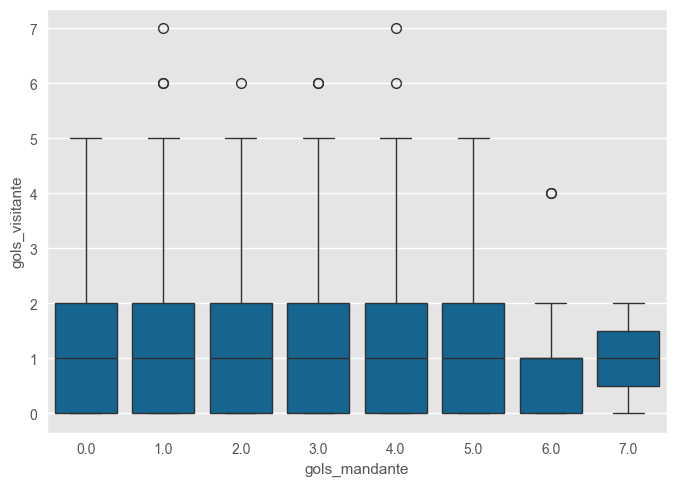

In [46]:
#  Boxplots: gols mandante vs visitante
sns.boxplot(
    data=df,
    x="gols_mandante",
    y="gols_visitante"
)

Identifique e interprete outliers
    
    Analisando este boxplot de uma forma geral, podemos enxergar que a principal quantia de gols geralmente fica entre 0 até 2 gols, indicando que a mioria das partidas ocorrerá isto, porém em poucos casos raros (outliers) podemos vez que o visitante se sobresai, então marcando acima de 2 gols, como 6 e 7 sendo outliers.

In [49]:
# Compare medidas de tendência central

Q1 = df['gols_mandante'].quantile(0.25)
Q3 = df['gols_mandante'].quantile(0.75)
InterQuartilMandante = Q3 - Q1

df_mandante = {
    "Média" : round(df["gols_mandante"].mean(), 3),
    "Mediana" :round(df["gols_mandante"].median(), 3),
    "Moda" :df['gols_mandante'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_mandante"].std(), 2),
    "IQR" :InterQuartilMandante
}

Q1 = df['gols_visitante'].quantile(0.25)
Q3 = df['gols_visitante'].quantile(0.75)
InterQuartilVisitante = Q3 - Q1

df_visitante = {
    "Média" : round(df["gols_visitante"].mean(), 3),
    "Mediana" :round(df["gols_visitante"].median(), 3),
    "Moda" :df['gols_visitante'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_visitante"].std(), 2),
    "IQR" :InterQuartilMandante
}

for key, value in df_mandante.items():
    print(f"Mandante: {key} tem valor: {value}")
    print(f"Visitante: {key} tem valor: {df_visitante[key]}")
    print("----------------------------------------------------")

Mandante: Média tem valor: 1.528
Visitante: Média tem valor: 1.023
----------------------------------------------------
Mandante: Mediana tem valor: 1.0
Visitante: Mediana tem valor: 1.0
----------------------------------------------------
Mandante: Moda tem valor: 1.0
Visitante: Moda tem valor: 0.0
----------------------------------------------------
Mandante: Desvio Padrão tem valor: 1.22
Visitante: Desvio Padrão tem valor: 1.02
----------------------------------------------------
Mandante: IQR tem valor: 1.0
Visitante: IQR tem valor: 1.0
----------------------------------------------------


## 3

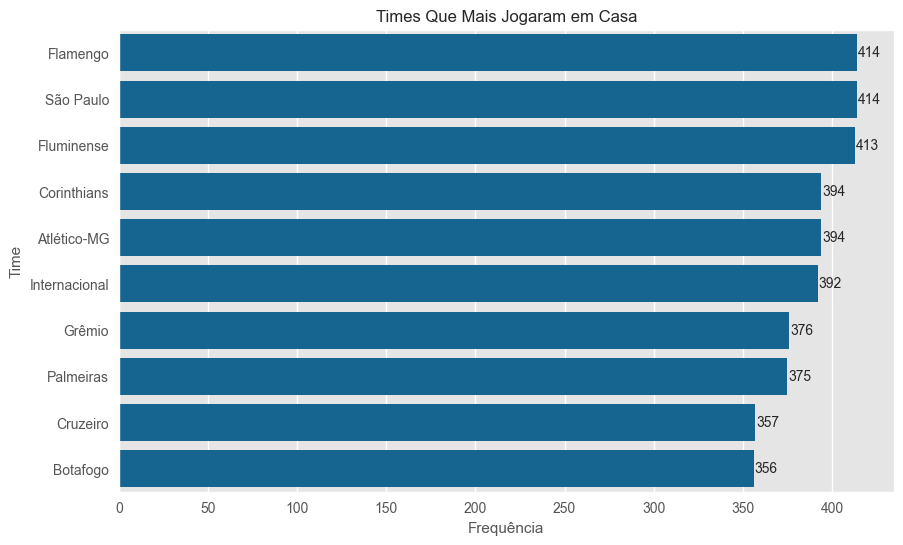

In [63]:
# Gráfico de barras: 10 times que mais jogaram em casa
top10 =df["time_mandante"].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10.values, y=top10.index)

for i, v in enumerate(top10.values):
    ax.text(v + 0.5, i, str(v), va="center")


plt.title("Times Que Mais Jogaram em Casa")
plt.xlabel("Frequência")
plt.ylabel("Time")
plt.show()

In [65]:
#Estatísticas descritivas do público (dados não-nulos)

In [66]:
df.columns

Index(['ano_campeonato', 'data', 'rodada', 'estadio', 'arbitro', 'publico',
       'publico_max', 'time_mandante', 'time_visitante', 'tecnico_mandante',
       'tecnico_visitante', 'colocacao_mandante', 'colocacao_visitante',
       'valor_equipe_titular_mandante', 'valor_equipe_titular_visitante',
       'idade_media_titular_mandante', 'idade_media_titular_visitante',
       'gols_mandante', 'gols_visitante', 'gols_1_tempo_mandante',
       'gols_1_tempo_visitante', 'escanteios_mandante', 'escanteios_visitante',
       'faltas_mandante', 'faltas_visitante', 'chutes_bola_parada_mandante',
       'chutes_bola_parada_visitante', 'defesas_mandante', 'defesas_visitante',
       'impedimentos_mandante', 'impedimentos_visitante', 'chutes_mandante',
       'chutes_visitante', 'chutes_fora_mandante', 'chutes_fora_visitante',
       'gols_total'],
      dtype='object')

In [70]:
df = df[~df["publico"].isna()]

In [73]:
Q1 = df['publico'].quantile(0.25)
Q3 = df['publico'].quantile(0.75)
InterQuartilPublico = Q3 - Q1

print(f"Média: {round(df["publico"].mean(), 2)} +- {round(df["publico"].std(), 2)}")
print(f"Mediana: {round(df["publico"].median(), 2)}")
print(f"IQR: {InterQuartilPublico}")

Média: 16189.95 +- 14074.41
Mediana: 12685.5
IQR: 17065.0


In [76]:
df["publico"].corr(df["gols_total"])

np.float64(-0.008456328713173726)

**A distribuição de gols é simétrica ou assimétrica? O que isso indica?**
A distribuição dos gols é assimétrica, indicando que não é uma distribuição normal, isso significa que não reproduz de forma fiel caso utilizarmos a medida de tendência central, média. A concentração de gols está inviesada aos menores valores, tendo uma assimetria a direita. 

**Há vantagem numérica do mando de campo**
Analisando a média de uma forma não absoluta (float) percebemos que os times que não visitantes, tem uma tendência maior de marcar mais gols, mesmo que não seja por um número exato, mesmo levando em consideração o desvio padrão no cálculo.

**Qual a relação entre público e gols**
Não existe nada que mostre fortemente uma correlação direta entre ambos, mas o que pode-se enxergar é que quanto maior a quantidade de gols, menor a quantidade de público.